# 09 — XGBoost Hyperparameter Tuning
---
**Purpose:** Use Optuna for Bayesian hyperparameter optimization and early stopping to lower the RMSE of the baseline XGBoost model.

**Input:** `train_data.parquet`, `val_data.parquet`, `test_data.parquet`
**Outputs:** 
- Saved optimized model (`xgboost_optimized.json`)
- Updated metrics (`xgboost_tuned_metrics.csv`)


In [1]:
import pandas as pd
import numpy as np
import os, warnings
import xgboost as xgb
import optuna
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

OUTPUT_DIR = os.path.join("..", "outputs")

print("Loading datasets...")
train_df = pd.read_parquet(os.path.join(OUTPUT_DIR, "data", "train_data.parquet"))
val_df = pd.read_parquet(os.path.join(OUTPUT_DIR, "data", "val_data.parquet"))
test_df = pd.read_parquet(os.path.join(OUTPUT_DIR, "data", "test_data.parquet"))

features = [
    'TyreAge', 'Log_TyreAge', 'StintLap', 'Compound_Encoded', 
    'RaceProgressFraction', 'TrackTemp', 'AirTemp', 
    'is_safety_car', 'is_vsc', 'Lag1_Pace_Residual', 
    'Rolling3_Degradation_Trend', 'Team_Median_Pace_Lag1'
]
target = 'Target_Tyre_Degradation'

X_train, y_train = train_df[features], train_df[target]
X_val, y_val = val_df[features], val_df[target]
X_test, y_test = test_df[features], test_df[target]

print(f"Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")


Loading datasets...
Train: 44,656 | Val: 7,932 | Test: 19,543


## 1. Optuna Objective Function
Define the search space and the objective (minimize RMSE on validation set).


In [2]:
def objective(trial):
    param = {
        'tree_method': 'hist',
        'random_state': 42,
        'n_estimators': 1000, # High number, rely on early stopping
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0.0, 5.0)
    }

    param['early_stopping_rounds'] = 30
    model = xgb.XGBRegressor(**param)
    
    # We use early stopping to prevent overfitting
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )
    
    preds = model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    return rmse

print("Starting Optuna study (this may take a few minutes)...")
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=30)

print(f"\nBest Trial: {study.best_trial.value:.5f}")
print("Best Params:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")


Starting Optuna study (this may take a few minutes)...



Best Trial: 0.64130
Best Params:
  learning_rate: 0.055771435326210636
  max_depth: 4
  subsample: 0.663182520670007
  colsample_bytree: 0.9490467414217628
  min_child_weight: 4
  gamma: 3.6649462416309007


## 2. Train Final Optimized Model


In [3]:
best_params = study.best_params
best_params['tree_method'] = 'hist'
best_params['random_state'] = 42
best_params['n_estimators'] = 1000

best_params['early_stopping_rounds'] = 50

print("Training final model with early stopping...")
final_model = xgb.XGBRegressor(**best_params)

final_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=100
)

print(f"\nStopped at iteration {final_model.best_iteration}")


Training final model with early stopping...
[0]	validation_0-rmse:2.31340	validation_1-rmse:1.62945


[100]	validation_0-rmse:0.63783	validation_1-rmse:0.64693


[181]	validation_0-rmse:0.59823	validation_1-rmse:0.65464



Stopped at iteration 131


## 3. Evaluation & Saving


In [4]:
def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    bias = np.mean(y_pred - y_true)
    return {'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2, 'Bias': bias}

# Predict
val_preds = final_model.predict(X_val)
test_preds = final_model.predict(X_test)

# Load old metrics for comparison
baseline_metrics_path = os.path.join(OUTPUT_DIR, 'reports', 'xgboost_baseline_metrics.csv')
if os.path.exists(baseline_metrics_path):
    metrics_df = pd.read_csv(baseline_metrics_path)
else:
    metrics_df = pd.DataFrame()

# Add new metrics
new_metrics = [
    evaluate_model('XGBoost Optimized (Val)', y_val, val_preds),
    evaluate_model('XGBoost Optimized (Test)', y_test, test_preds)
]
final_metrics_df = pd.concat([metrics_df, pd.DataFrame(new_metrics)], ignore_index=True)

display(final_metrics_df)

# Save
model_path = os.path.join(OUTPUT_DIR, "models", "xgboost_optimized.json")
final_model.save_model(model_path)
final_metrics_df.to_csv(os.path.join(OUTPUT_DIR, "reports", "xgboost_tuned_metrics.csv"), index=False)

print(f"Saved optimized model to {model_path}")


,Model,MAE,RMSE,R2,Bias
0,Global Mean,1.257936,1.714104,-0.077493,-0.459686
1,Linear Reg (TyreAge Only),1.197348,1.633060,0.021987,-0.404808
2,Multiple Linear Reg,0.939714,1.481934,0.194626,-0.000815
3,XGBoost Baseline,0.440426,0.708557,0.815885,0.007545
4,XGBoost Baseline (TEST SET 2025),0.423728,0.718566,0.841078,0.035010
5,XGBoost Optimized (Val),0.390290,0.641299,0.849179,0.033516
6,XGBoost Optimized (Test),0.381036,0.652715,0.868872,0.032167


Saved optimized model to ..\outputs\models\xgboost_optimized.json


## 4. Visualizations
Visualizing the performance of the Optimized XGBoost Model to see how closely predictions match actual degradation.

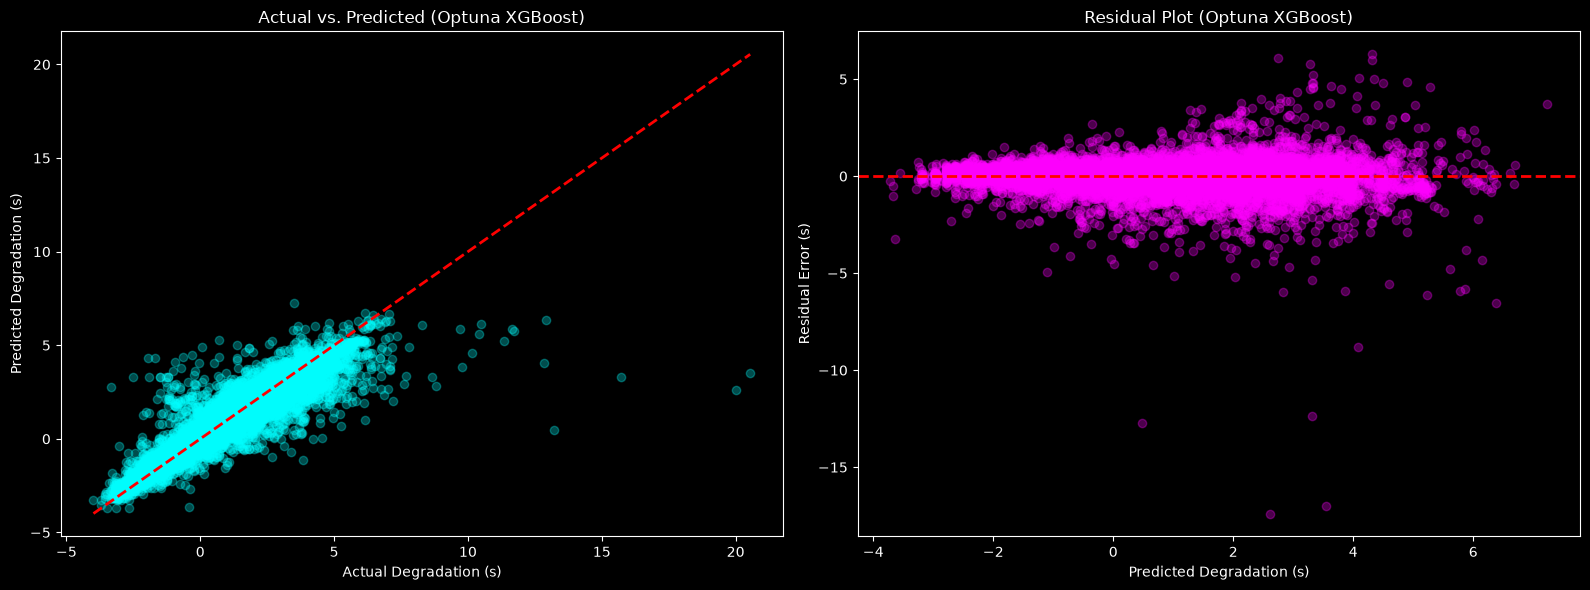

Saved visualization to ..\outputs\plots\xgboost_tuned_visualizations.png


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('dark_background')
sns.set_palette("husl")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Actual vs Predicted (Test Set)
axes[0].scatter(y_test, test_preds, alpha=0.3, color='cyan')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Degradation (s)')
axes[0].set_ylabel('Predicted Degradation (s)')
axes[0].set_title('Actual vs. Predicted (Optuna XGBoost)')

# 2. Residual Plot (Test Set)
residuals = test_preds - y_test
axes[1].scatter(test_preds, residuals, alpha=0.3, color='magenta')
axes[1].axhline(0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Degradation (s)')
axes[1].set_ylabel('Residual Error (s)')
axes[1].set_title('Residual Plot (Optuna XGBoost)')

plt.tight_layout()
plt.show()

# Save the plots
os.makedirs(os.path.join(OUTPUT_DIR, "plots"), exist_ok=True)
fig.savefig(os.path.join(OUTPUT_DIR, "plots", "xgboost_tuned_visualizations.png"), bbox_inches='tight', dpi=300)
print(f"Saved visualization to {os.path.join(OUTPUT_DIR, 'plots', 'xgboost_tuned_visualizations.png')}")
